# Prediccion del Tipo de Cambio USD/GEL con Chronos (Amazon)
### Modelo preentrenado — sin entrenamiento adicional

## Instalacion

In [1]:
!pip install chronos-forecasting


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importaciones

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from chronos import ChronosPipeline
from sklearn.metrics import mean_squared_error

torch.manual_seed(42)
np.random.seed(42)
print('Listo')

c:\Users\Usuario\Desktop\INTELIG. ARTIF. 2\IA_2\venv_ia\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Listo


## Carga del Dataset

In [3]:
RUTA = r'C:\Users\Usuario\Desktop\INTELIG. ARTIF. 2\P1\DATASET\DatasetLARI\USD_GEL Historical Data.csv'

df = pd.read_csv(RUTA)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Rango: {df["Date"].iloc[0].date()}  a  {df["Date"].iloc[-1].date()}')
print(f'Filas: {len(df)}')
df.head()

Rango: 2001-05-11  a  2020-10-27
Filas: 4999


,Date,Price,Open,High,Low,Vol.,Change %
0,2001-05-11,2.0550,2.0550,2.0550,2.0550,NaN,0.24%
1,2001-05-14,2.0570,2.0570,2.0570,2.0570,NaN,0.10%
2,2001-05-15,2.0595,2.0595,2.0595,2.0595,NaN,0.12%
3,2001-05-16,2.0650,2.0650,2.0650,2.0650,NaN,0.27%
4,2001-05-17,2.0700,2.0700,2.0700,2.0700,NaN,0.24%


## Preparacion de la serie

Chronos solo necesita la serie historica de precios de cierre (`Price`). No requiere normalizacion ni ventanas manuales, eso lo hace internamente el modelo.

In [4]:
ULTIMO_MES  = 22
DIAS_FUTURO = 30

serie_completa  = df['Price'].values.astype(np.float32)

serie_train     = serie_completa[:-ULTIMO_MES]
precios_reales  = serie_completa[-ULTIMO_MES:]
fechas_test     = df['Date'].iloc[-ULTIMO_MES:].values

print(f'Serie para contexto : {len(serie_train)} dias')
print(f'Dias a predecir     : {ULTIMO_MES} (test) + {DIAS_FUTURO} (futuro)')

Serie para contexto : 4977 dias
Dias a predecir     : 22 (test) + 30 (futuro)


## Carga del Modelo Chronos

`chronos-t5-small` es la version liviana. Existen versiones mas grandes (`base`, `large`) pero para este dataset `small` es suficiente y mucho mas rapido.

In [5]:
pipeline = ChronosPipeline.from_pretrained(
    'amazon/chronos-t5-small',
    device_map = 'cpu',
    torch_dtype= torch.float32
)
print('Modelo cargado')

c:\Users\Usuario\Desktop\INTELIG. ARTIF. 2\IA_2\venv_ia\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Usuario\.cache\huggingface\hub\models--amazon--chronos-t5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
`torch_dtype` is deprecated! Use `dtype` instead!
Xet Storage is enabled for this repo,

Modelo cargado


## Prediccion sobre el Test Set (22 dias ocultos)

Le pasamos toda la historia hasta antes del mes oculto y le pedimos que prediga exactamente esos 22 dias.

In [7]:
contexto = torch.tensor(serie_train).unsqueeze(0)

forecast = pipeline.predict(
    contexto,
    ULTIMO_MES,
    num_samples = 20
)

preds_test = forecast[0].mean(axis=0).numpy()

print(f'Predicciones generadas: {preds_test.shape[0]} dias')

Predicciones generadas: 22 dias


## Metricas sobre el Test Set

In [8]:
mse  = mean_squared_error(precios_reales, preds_test)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(precios_reales - preds_test))
mape = np.mean(np.abs((precios_reales - preds_test) / precios_reales)) * 100

print('Metricas sobre el Test Set (22 dias ocultos)')
print('-' * 40)
print(f'  MSE  : {mse:.6f}')
print(f'  RMSE : {rmse:.6f}')
print(f'  MAE  : {mae:.6f}')
print(f'  MAPE : {mape:.4f}%')

Metricas sobre el Test Set (22 dias ocultos)
----------------------------------------
  MSE  : 0.019435
  RMSE : 0.139408
  MAE  : 0.133160
  MAPE : 4.1538%


## Grafica: Prediccion vs Real (Test Set)

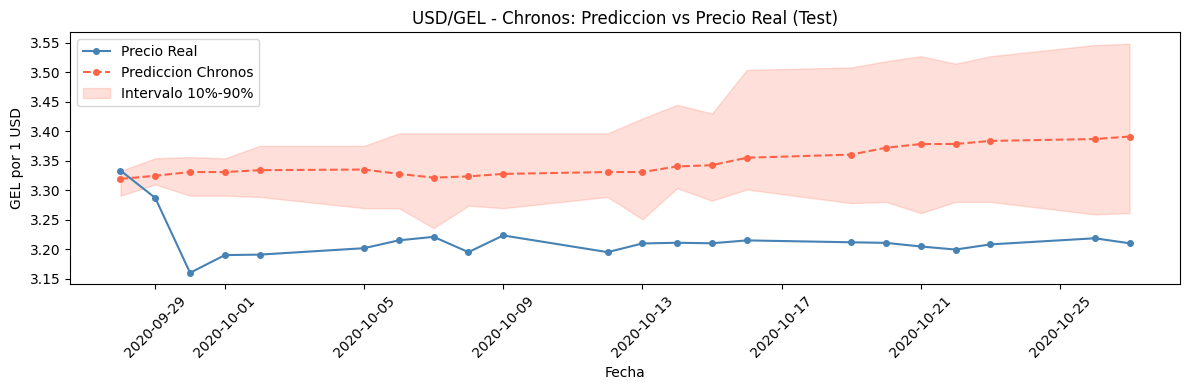

     Fecha   Real  Prediccion  Error Abs
2020-09-28 3.3332      3.3191     0.0141
2020-09-29 3.2868      3.3244     0.0376
2020-09-30 3.1600      3.3307     0.1707
2020-10-01 3.1900      3.3307     0.1407
2020-10-02 3.1908      3.3339     0.1431
2020-10-05 3.2017      3.3349     0.1332
2020-10-06 3.2150      3.3275     0.1125
2020-10-07 3.2209      3.3212     0.1003
2020-10-08 3.1950      3.3233     0.1283
2020-10-09 3.2233      3.3275     0.1042
2020-10-12 3.1950      3.3307     0.1357
2020-10-13 3.2097      3.3307     0.1210
2020-10-14 3.2109      3.3402     0.1293
2020-10-15 3.2100      3.3423     0.1323
2020-10-16 3.2149      3.3550     0.1401
2020-10-19 3.2117      3.3602     0.1485
2020-10-20 3.2107      3.3718     0.1611
2020-10-21 3.2046      3.3782     0.1736
2020-10-22 3.1994      3.3782     0.1788
2020-10-23 3.2081      3.3834     0.1753
2020-10-26 3.2185      3.3866     0.1681
2020-10-27 3.2100      3.3908     0.1808


In [9]:
low  = np.quantile(forecast[0].numpy(), 0.1, axis=0)
high = np.quantile(forecast[0].numpy(), 0.9, axis=0)

plt.figure(figsize=(12, 4))
plt.plot(fechas_test, precios_reales, color='steelblue', linewidth=1.5, marker='o', markersize=4, label='Precio Real')
plt.plot(fechas_test, preds_test,     color='tomato',    linewidth=1.5, marker='o', markersize=4, label='Prediccion Chronos', linestyle='--')
plt.fill_between(fechas_test, low, high, alpha=0.2, color='tomato', label='Intervalo 10%-90%')
plt.title('USD/GEL - Chronos: Prediccion vs Precio Real (Test)')
plt.xlabel('Fecha')
plt.ylabel('GEL por 1 USD')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

comparativa = pd.DataFrame({
    'Fecha'     : fechas_test,
    'Real'      : precios_reales.round(4),
    'Prediccion': preds_test.round(4),
    'Error Abs' : np.abs(precios_reales - preds_test).round(4)
})
print(comparativa.to_string(index=False))

## Prediccion de 30 Dias Futuros

In [10]:
contexto_full = torch.tensor(serie_completa).unsqueeze(0)

forecast_fut = pipeline.predict(
    contexto_full,
    DIAS_FUTURO,
    num_samples = 20
)

preds_futuro = forecast_fut[0].mean(axis=0).numpy()
low_fut      = np.quantile(forecast_fut[0].numpy(), 0.1, axis=0)
high_fut     = np.quantile(forecast_fut[0].numpy(), 0.9, axis=0)

ultima_fecha  = df['Date'].iloc[-1]
fechas_futuro = pd.date_range(start=ultima_fecha + pd.Timedelta(days=1), periods=DIAS_FUTURO, freq='B')

df_futuro = pd.DataFrame({
    'Fecha'     : fechas_futuro,
    'Prediccion': preds_futuro.round(4),
    'Low 10%'   : low_fut.round(4),
    'High 90%'  : high_fut.round(4)
})
print(df_futuro.to_string(index=False))

     Fecha  Prediccion  Low 10%  High 90%
2020-10-28      3.2117   3.2106    3.2128
2020-10-29      3.2223   3.1894    3.2340
2020-10-30      3.2244   3.1894    3.2532
2020-11-02      3.2223   3.1894    3.2553
2020-11-03      3.2213   3.1872    3.2361
2020-11-04      3.2064   3.1660    3.2595
2020-11-05      3.2042   3.1660    3.2574
2020-11-06      3.2053   3.1468    3.2765
2020-11-09      3.2074   3.1830    3.2765
2020-11-10      3.2064   3.1639    3.2957
2020-11-11      3.2021   3.1639    3.2957
2020-11-12      3.2000   3.1447    3.2978
2020-11-13      3.2042   3.1447    3.3169
2020-11-16      3.2032   3.1660    3.2978
2020-11-17      3.2021   3.1447    3.2978
2020-11-18      3.1915   3.1235    3.2978
2020-11-19      3.1872   3.1213    3.2957
2020-11-20      3.1872   3.1213    3.2957
2020-11-23      3.1702   3.0809    3.2765
2020-11-24      3.1681   3.0979    3.2957
2020-11-25      3.1755   3.0979    3.3169
2020-11-26      3.1787   3.0788    3.3169
2020-11-27      3.1766   3.0809   

## Grafica: Predicciones Futuras

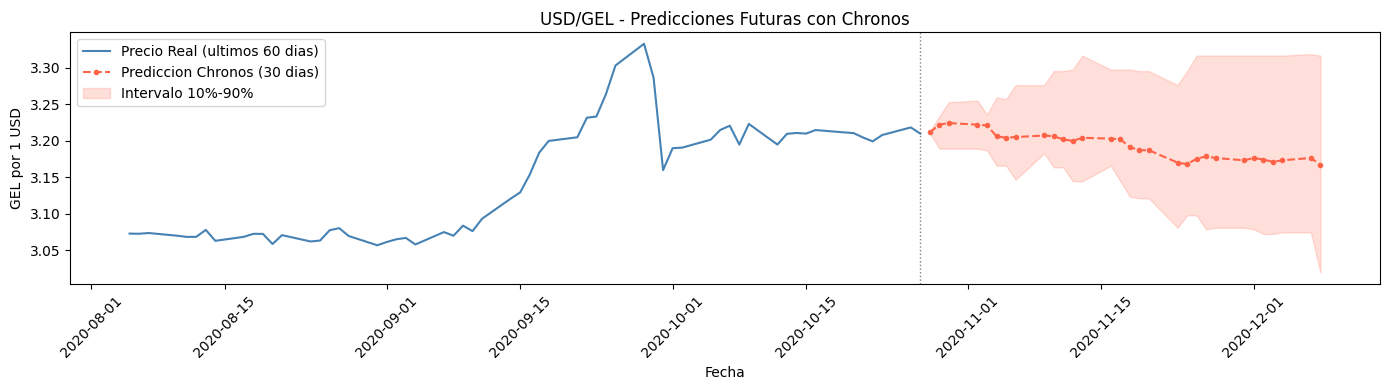

In [11]:
ultimos_reales = df['Price'].iloc[-60:].values
fechas_reales  = df['Date'].iloc[-60:].values

plt.figure(figsize=(14, 4))
plt.plot(fechas_reales,  ultimos_reales,  color='steelblue', linewidth=1.5, label='Precio Real (ultimos 60 dias)')
plt.plot(fechas_futuro,  preds_futuro,    color='tomato',    linewidth=1.5, linestyle='--', marker='o', markersize=3, label=f'Prediccion Chronos ({DIAS_FUTURO} dias)')
plt.fill_between(fechas_futuro, low_fut, high_fut, alpha=0.2, color='tomato', label='Intervalo 10%-90%')
plt.axvline(x=ultima_fecha, color='gray', linestyle=':', linewidth=1)
plt.title('USD/GEL - Predicciones Futuras con Chronos')
plt.xlabel('Fecha')
plt.ylabel('GEL por 1 USD')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Resumen Final

In [ ]:
print('=' * 55)
print('      RESUMEN FINAL - CHRONOS USD/GEL')
print('=' * 55)

print(f'\nDATASET')
print(f'  Rango            : {df["Date"].iloc[0].date()} a {df["Date"].iloc[-1].date()}')
print(f'  Total dias       : {len(df)}')

print(f'\nMODELO')
print(f'  Nombre           : Amazon Chronos T5 Small')
print(f'  Entrenamiento    : Ninguno (modelo preentrenado)')
print(f'  Contexto usado   : {len(serie_train)} dias historicos')
print(f'  Muestras         : 20')

print(f'\nMETRICAS TEST SET ({ULTIMO_MES} dias ocultos)')
print(f'  MSE  : {mse:.6f}')
print(f'  RMSE : {rmse:.6f}')
print(f'  MAE  : {mae:.6f}')
print(f'  MAPE : {mape:.4f}%')

print(f'\nPREDICCIONES FUTURAS ({DIAS_FUTURO} dias habiles)')
print(f'  Desde : {fechas_futuro[0].date()}')
print(f'  Hasta : {fechas_futuro[-1].date()}')
print(f'  Min   : {preds_futuro.min():.4f} GEL')
print(f'  Max   : {preds_futuro.max():.4f} GEL')
print(f'  Media : {preds_futuro.mean():.4f} GEL')
print(f'  Ultimo precio real conocido: {df["Price"].iloc[-1]:.4f} GEL')


      RESUMEN FINAL - CHRONOS USD/GEL

DATASET
  Rango            : 2001-05-11 a 2020-10-27
  Total dias       : 4999

MODELO
  Nombre           : Amazon Chronos T5 Small
  Entrenamiento    : Ninguno (modelo preentrenado)
  Contexto usado   : 4977 dias historicos
  Muestras         : 20

METRICAS TEST SET (22 dias ocultos)
  MSE  : 0.019435
  RMSE : 0.139408
  MAE  : 0.133160
  MAPE : 4.1538%

PREDICCIONES FUTURAS (30 dias habiles)
  Desde : 2020-10-28
  Hasta : 2020-12-08
  Min   : 3.1670 GEL
  Max   : 3.2244 GEL
  Media : 3.1930 GEL
  Ultimo precio real conocido: 3.2100 GEL

Copia este bloque y mandamelo para comparar con MLP.
